In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
df = pd.read_csv("C:/Users/DIVYANSHU SINGH/Downloads/jupyter notebook/excel file/Netflix/moviedb.csv", encoding="latin1")

In [3]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,15-12-2021,Spider-Man: No Way Home,5083.95,8940.0,8.3,en,"Action, Adventure, Science Fiction"
1,01-03-2022,The Batman,3827.66,1151.0,8.1,en,"Crime, Mystery, Thriller"
2,25-02-2022,No Exit,2618.09,122.0,6.3,en,Thriller
3,24-11-2021,Encanto,2402.20,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy"
4,22-12-2021,The King's Man,1895.51,1793.0,7.0,en,"Action, Adventure, Thriller, War"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9828 entries, 0 to 9827
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9828 non-null   object 
 1   Title              9828 non-null   object 
 2   Popularity         9828 non-null   float64
 3   Vote_Count         9828 non-null   float64
 4   Vote_Average       9828 non-null   float64
 5   Original_Language  9828 non-null   object 
 6   Genre              9828 non-null   object 
dtypes: float64(3), object(4)
memory usage: 537.6+ KB


In [5]:
df['Title'] = df['Title'].astype('string')
df['Original_Language'] = df['Original_Language'].astype('string')
df['Genre'] = df['Genre'].astype('string')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9828 entries, 0 to 9827
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9828 non-null   object 
 1   Title              9828 non-null   string 
 2   Popularity         9828 non-null   float64
 3   Vote_Count         9828 non-null   float64
 4   Vote_Average       9828 non-null   float64
 5   Original_Language  9828 non-null   string 
 6   Genre              9828 non-null   string 
dtypes: float64(3), object(1), string(3)
memory usage: 537.6+ KB


In [7]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9828.000000,9828.000000,9828.000000
mean,40.325825,1392.140720,6.439438
std,108.868416,2610.870392,1.129676
min,13.350000,0.000000,0.000000
25%,16.130000,146.000000,5.900000
50%,21.200000,444.000000,6.500000
75%,35.185000,1375.250000,7.100000
max,5083.950000,31077.000000,10.000000


In [8]:
df.drop(['Original_Language'], axis = 1, inplace = True)

In [9]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,15-12-2021,Spider-Man: No Way Home,5083.95,8940.0,8.3,"Action, Adventure, Science Fiction"
1,01-03-2022,The Batman,3827.66,1151.0,8.1,"Crime, Mystery, Thriller"
2,25-02-2022,No Exit,2618.09,122.0,6.3,Thriller
3,24-11-2021,Encanto,2402.20,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,22-12-2021,The King's Man,1895.51,1793.0,7.0,"Action, Adventure, Thriller, War"


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9828 entries, 0 to 9827
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9828 non-null   object 
 1   Title         9828 non-null   string 
 2   Popularity    9828 non-null   float64
 3   Vote_Count    9828 non-null   float64
 4   Vote_Average  9828 non-null   float64
 5   Genre         9828 non-null   string 
dtypes: float64(3), object(1), string(2)
memory usage: 460.8+ KB


In [11]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], dayfirst = True)
print(df['Release_Date'].dtypes)

datetime64[ns]


In [12]:
df['Release_Date'] = df['Release_Date'].dt.year

In [13]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.95,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.66,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.09,122.0,6.3,Thriller
3,2021,Encanto,2402.20,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.51,1793.0,7.0,"Action, Adventure, Thriller, War"


In [14]:
def catigorize_col(df,col,label):

    edegs = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col], edegs, labels = labels, duplicates = 'drop')
    return df

In [15]:
labels = ['not_popular', 'below_avg', 'avg', 'polular']


catigorize_col(df, 'Vote_Average', labels)



,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.95,8940.0,polular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.66,1151.0,polular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.09,122.0,below_avg,Thriller
3,2021,Encanto,2402.20,5076.0,polular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.51,1793.0,avg,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9823,1973,Badlands,13.36,896.0,polular,"Drama, Crime"
9824,2020,Violent Delights,13.36,8.0,not_popular,Horror
9825,2016,The Offering,13.36,94.0,not_popular,"Mystery, Thriller, Horror"
9826,2021,The United States vs. Billie Holiday,13.35,152.0,avg,"Music, Drama, History"


In [16]:
df['Vote_Average'].unique()

['polular', 'below_avg', 'avg', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'avg' < 'polular']

In [17]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
polular        2449
avg            2413
below_avg      2399
Name: count, dtype: int64

In [18]:
df.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [19]:
df.dropna( inplace = True)

In [20]:
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [21]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop = True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.95,8940.0,polular,Action
1,2021,Spider-Man: No Way Home,5083.95,8940.0,polular,Adventure
2,2021,Spider-Man: No Way Home,5083.95,8940.0,polular,Science Fiction
3,2022,The Batman,3827.66,1151.0,polular,Crime
4,2022,The Batman,3827.66,1151.0,polular,Mystery


In [22]:
df['Genre'] = df['Genre'].str.strip()

In [23]:
df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Adventure,Action', 'Animation',
                  'Comedy', 'Crime', 'Documentary', 'Drama', 'Family',
                  'Fantasy', 'History', 'Horror', 'Music', 'Mystery',
                  'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War',
                  'Western'],
, ordered=False, categories_dtype=object)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25549 entries, 0 to 25548
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25549 non-null  int32   
 1   Title         25549 non-null  string  
 2   Popularity    25549 non-null  float64 
 3   Vote_Count    25549 non-null  float64 
 4   Vote_Average  25549 non-null  category
 5   Genre         25549 non-null  category
dtypes: category(2), float64(2), int32(1), string(1)
memory usage: 749.5 KB


In [25]:
df.nunique()

Release_Date     100
Title           9416
Popularity      3975
Vote_Count      3265
Vote_Average       4
Genre             20
dtype: int64

## Data Visualization

### What is the most frequent genre of movies released on Netflix?

In [26]:
df['Genre'].describe()

count     25549
unique       20
top       Drama
freq       3716
Name: Genre, dtype: object

In [27]:
sn.set_style('whitegrid')

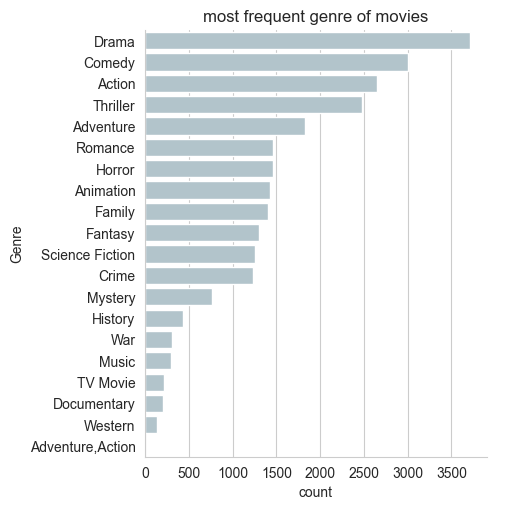

In [28]:
sn.catplot(y = 'Genre', data = df, kind = 'count',
           order = df['Genre'].value_counts().index,
           color = '#AEC6CF' )
plt.title('most frequent genre of movies')
plt.show()

### Which has the highest voting in Vote_Average column?

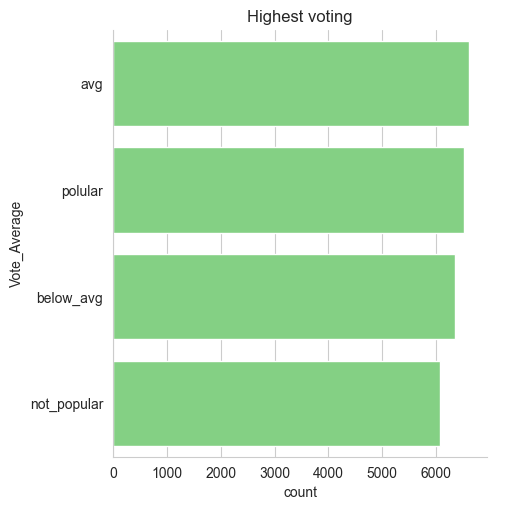

In [29]:
sn.catplot(y = 'Vote_Average', data = df, kind = 'count',
           order = df['Vote_Average'].value_counts().index,
           color = '#77DD77' )
plt.title('Highest voting')
plt.show()

### What movie got the higest popularity? what's its genre?

In [30]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.95,8940.0,polular,Action
1,2021,Spider-Man: No Way Home,5083.95,8940.0,polular,Adventure
2,2021,Spider-Man: No Way Home,5083.95,8940.0,polular,Science Fiction


### What movie got the lowest popularity? what's its genre?

In [31]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25543,2021,The United States vs. Billie Holiday,13.35,152.0,avg,Music
25544,2021,The United States vs. Billie Holiday,13.35,152.0,avg,Drama
25545,2021,The United States vs. Billie Holiday,13.35,152.0,avg,History
25546,1984,Threads,13.35,186.0,polular,War
25547,1984,Threads,13.35,186.0,polular,Drama
25548,1984,Threads,13.35,186.0,polular,Science Fiction


### Which year has the most filmmed movies

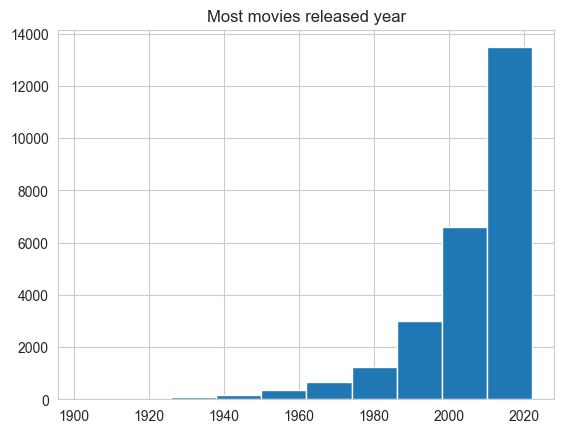

In [33]:
df['Release_Date'].hist()

plt.title('Most movies released year')
plt.show()